# Анализ вероятности дефолта заёмщика



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [52]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch

import statsmodels.api as sm
import statsmodels.formula.api as smf

from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid, KFold, RandomizedSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

## 1. Описание данных

**Источник.** Credit Risk Dataset by Lao Tse, Kaggle:
<https://www.kaggle.com/datasets/laotse/credit-risk-dataset>.

**Объём.** $n = 32\,581$ наблюдение, 12 признаков. Целевая `loan_status ∈ {0, 1}`:
$1$ — дефолт (заёмщик не вернул кредит), $0$ — кредит погашен.

В нашем случае данные не имеют указания о своем происхождении -- за какой год или годы они собраны, в какой стране. Можно предположить, судя по системе оценок заемщика, что собирались они в США.

**Описание переменных.**

| Колонка | Тип | Содержание |
|---|---|---|
| `person_age` | int | Возраст заёмщика |
| `person_income` | int | Годовой доход |
| `person_home_ownership` | str | RENT / OWN / MORTGAGE / OTHER |
| `person_emp_length` | float | Стаж |
| `loan_intent` | str | Цель кредита |
| `loan_grade` | str | Рейтинг A–G |
| `loan_amnt` | int | Сумма кредита |
| `loan_int_rate` | float | Процентная ставка |
| `loan_status` | int | **Целевая** |
| `loan_percent_income` | float | Доля кредита в годовом доходе |
| `cb_person_default_on_file` | str | Y/N — есть ли дефолты в кредитной истории |
| `cb_person_cred_hist_length` | int | Длина кредитной истории (лет) |


In [3]:
data_raw = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
print(f"Размер: {data_raw.shape[0]:,} наблюдений × {data_raw.shape[1]} признаков")
print(f"Доля дефолтов (loan_status=1): {data_raw['loan_status'].mean():.4f}")
data_raw.head()

Размер: 32,581 наблюдений × 12 признаков
Доля дефолтов (loan_status=1): 0.2182


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
info_df = pd.DataFrame({
    'dtype':       data_raw.dtypes.astype(str),
    'n_missing':   data_raw.isna().sum(),
    'pct_missing': (data_raw.isna().mean() * 100).round(2),
    'n_unique':    data_raw.nunique(),
})
print('Типы данных и пропуски:')
info_df

Типы данных и пропуски:


,dtype,n_missing,pct_missing,n_unique
person_age,int64,0,0.00,58
person_income,int64,0,0.00,4295
person_home_ownership,object,0,0.00,4
person_emp_length,float64,895,2.75,36
loan_intent,object,0,0.00,6
loan_grade,object,0,0.00,7
loan_amnt,int64,0,0.00,753
loan_int_rate,float64,3116,9.56,348
loan_status,int64,0,0.00,2
loan_percent_income,float64,0,0.00,77


Понятно, что максимальный возраст -- 144 года, это очень много и такого быть не может (максимально задокументированный возраст 122 года), поэтому в дальнейшем нашей цклью булет избавиться от таких выбросов. Также у нас есть пропущенные переменные. Строки с ними мы будем отбрасывать.

In [5]:
data_raw.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


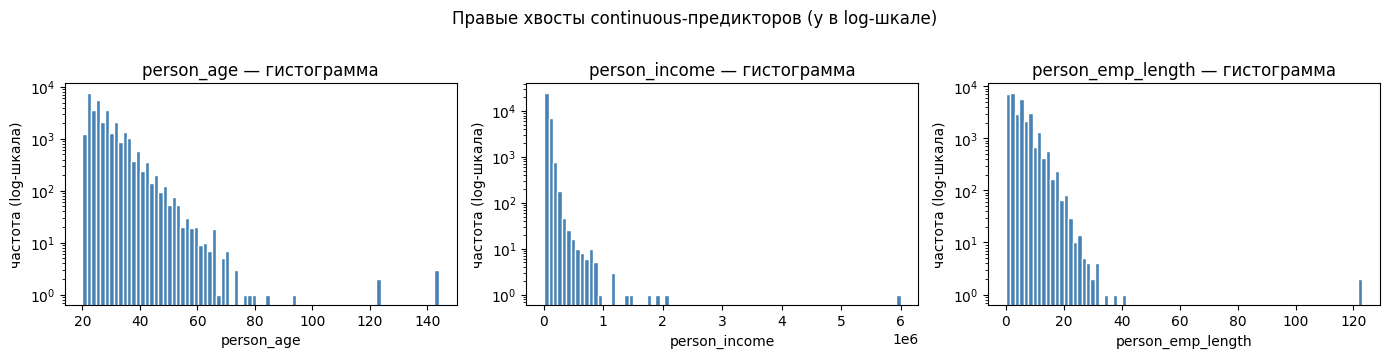

In [6]:
cols_with_tails = ['person_age', 'person_income', 'person_emp_length']

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for j, col in enumerate(cols_with_tails):
    s = data_raw[col].dropna()
    axes[j].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[j].set_title(f'{col} — гистограмма')
    axes[j].set_yscale('log')
    axes[j].set_ylabel('частота (log-шкала)')
    axes[j].set_xlabel(col)
fig.suptitle('Правые хвосты continuous-предикторов (y в log-шкале)', y=1.01)
fig.tight_layout()
plt.show()

Мы видим, что в случае возраста и стажа есть опреденные выбросы. Построим оптимальную стратегию для того, чтобы эти выбросы уустранить, а именно -- подберем порог, и если возраст объекта выше, чем этот порог, то мы этот объект удалим.

In [7]:
thresholds = [60, 80, 100, 120, 200]  # 200 = без ограничения сверху
rows = []
for t in thresholds:
    mask = data_raw['person_age'] <= t
    rows.append({
        'порог age ≤':  t,
        'n':            int(mask.sum()),
        'удалено':      int((~mask).sum()),
        'mean(Y)':      round(float(data_raw.loc[mask, 'loan_status'].mean()), 4),
        'mean(age)':    round(float(data_raw.loc[mask, 'person_age'].mean()), 2),
        'max(age)':     int(data_raw.loc[mask, 'person_age'].max()),
    })
sens_age = pd.DataFrame(rows)
sens_age

,порог age ≤,n,удалено,mean(Y),mean(age),max(age)
0,60,32511,70,0.2181,27.64,60
1,80,32574,7,0.2182,27.71,80
2,100,32576,5,0.2182,27.72,94
3,120,32576,5,0.2182,27.72,94
4,200,32581,0,0.2182,27.73,144


Пример порог, равный 80, так как больше него единичное количество значений, поэтому на оценку модели это никак не повлияет.

Для `emp_length` применяем ограничение
$$\text{emp_length}_i \le \text{age}_i - 14,$$
поскольку работать можно только с 14 лет.



Теперь удалим строки с пропущенными переменными, а также применим введенные нами ограничения.

In [8]:
data = data_raw.copy()

data = data[data['person_age'] <= 80]

emp_ok = data['person_emp_length'].isna() | (data['person_emp_length'] <= data['person_age'] - 14)
data = data[emp_ok]

data = data.dropna().reset_index(drop=True)


In [9]:
data.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,28631.00,28631.00,28631.00,28631.00,28631.00,28631.00,28631.00,28631.00
mean,27.71,66425.51,4.78,9655.32,11.04,0.22,0.17,5.79
std,6.16,51548.08,4.04,6327.91,3.23,0.41,0.11,4.04
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,39456.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55900.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,80000.00,7.00,12500.00,13.48,0.00,0.23,8.00
max,80.00,2039784.00,41.00,35000.00,23.22,1.00,0.83,30.00


Теперь нам предстоит закодировать переменные. Для некоторых, даже порядковых переменных, например, grade, порядковое кодирование 1,...,7 может не подойти, так как скачки от класса к классу в плане надежности заемщика могут быть разные, а они и есть разные, поэтому OneHotEncoding, или как его еще называют дамми-кодирование, может быть уместно и в этом случае.
**Принцип кодирования:**

- `cb_person_default_on_file` → `prev_default ∈ {0, 1}`.
- `person_home_ownership` → 3 dummy переменные, за базовую берем `MORTGAGE`, что соотвесвтует ипотеке, так как это наиболее часто стречабщаяся в данных категория.
- `loan_intent` → 5 dummy, за базовую берем `PERSONAL`.
- `loan_grade`: опять дамми переменные с базовой = `A`
- `person_income`: прологарифмируем эту переменную, так как в случае с доходом важно приращение 'во сколько раз', а не насколько денег.



Мы, однако, все же оставим grade_ord как порядковую -- для более удобного анализа, но перед началом построения модели этот столбец мы уберем. Точно также поступим и с person_income, который временно оставим, впоследствии окончательно заменив его на log_income.

In [10]:
data['prev_default'] = (data['cb_person_default_on_file'] == 'Y').astype(int)
data = data.drop(columns=['cb_person_default_on_file'])

data['_grade_orig']  = data['loan_grade']
data['_home_orig']   = data['person_home_ownership']
data['_intent_orig'] = data['loan_intent']

home_dummies = pd.get_dummies(data['person_home_ownership'],
                              prefix='home', dtype=int).drop(columns='home_MORTGAGE')
data = pd.concat([data, home_dummies], axis=1).drop(columns=['person_home_ownership'])

intent_dummies = pd.get_dummies(data['loan_intent'],
                                prefix='intent', dtype=int).drop(columns='intent_PERSONAL')
data = pd.concat([data, intent_dummies], axis=1).drop(columns=['loan_intent'])

gr_mp = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_ord'] = data['loan_grade'].map(gr_mp).astype(int)
grade_dummies = pd.get_dummies(data['loan_grade'],
                               prefix='grade', dtype=int).drop(columns='grade_A')
grade_dummies = pd.get_dummies(data['loan_grade'],
                               prefix='grade', dtype=int).drop(columns='grade_A')
data = pd.concat([data, grade_dummies], axis=1).drop(columns=['loan_grade'])

data['log_income'] = np.log(data['person_income'])


В наших данных уже есть grade, установленный сотрудниками банка, поэтому будет логично их сгруппировать и посмотреть на то, как зависят некоторые признаки от этого самого grade.

In [11]:
stat_by_grade = data.groupby('_grade_orig').agg(
    n=('loan_status', 'size'),
    default_rate=('loan_status', 'mean'),
    mean_age=('person_age', 'mean'),
    mean_income=('person_income', 'mean'),
    mean_lpi=('loan_percent_income', 'mean'),
    mean_amnt=('loan_amnt', 'mean'),
    mean_int_rate=('loan_int_rate', 'mean'),
).round(3)
stat_by_grade.index.name = 'grade'
print('Описательные статистики по grade:')
stat_by_grade

Описательные статистики по grade:


,n,default_rate,mean_age,mean_income,mean_lpi,mean_amnt,mean_int_rate
grade,,,,,,,
A,9400,0.096,27.669,67012.451,0.153,8577.261,7.347
B,9149,0.159,27.638,66780.499,0.174,10055.946,11.002
C,5697,0.203,27.731,64773.938,0.170,9302.141,13.453
D,3247,0.592,27.933,64244.273,0.190,10871.874,15.349
E,870,0.646,27.745,71174.186,0.205,12929.109,17.006
F,209,0.699,28.392,80079.230,0.219,15308.014,18.597
G,59,0.983,28.322,78994.898,0.254,18141.949,20.252


Отсюда видно, что действительно рейтинг банка очень сильный предиктор, так как люди с самым плохим рейтингом почти никогда не возвращают свои займы.

Посмотрим теперь тоже самое, только в зависимости от того -- был ранее дефолт или же нет.

In [12]:
stat_by_prev = data.groupby('prev_default').agg(
    n=('loan_status', 'size'),
    default_rate=('loan_status', 'mean'),
    mean_age=('person_age', 'mean'),
    mean_income=('log_income', 'mean'),
    mean_grade=('grade_ord', 'mean'),
    mean_lpi=('loan_percent_income', 'mean'),
).round(3)
stat_by_prev.index = stat_by_prev.index.map({0: 'no prior default', 1: 'prior default'})

stat_by_prev

,n,default_rate,mean_age,mean_income,mean_grade,mean_lpi
prev_default,,,,,,
no prior default,23529,0.182,27.683,10.942,1.936,0.168
prior default,5102,0.377,27.834,10.916,3.575,0.178


Здесь видим, что люди, которые свои долги не возвращали раньше, не возвращают новый долг более чем в 2 раза чаще, чем те, кто свои старые долги возвращали. При этом  

Посмотрим на матрицу корреляций наших признаков.

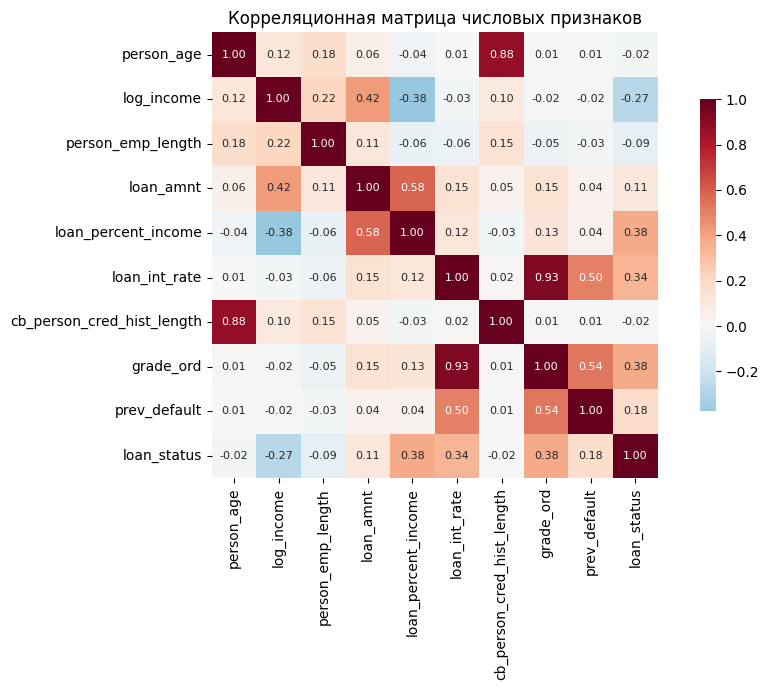

In [13]:
num_cols = ['person_age',  'log_income', 'person_emp_length',
            'loan_amnt', 'loan_percent_income', 'loan_int_rate',
            'cb_person_cred_hist_length', 'grade_ord', 'prev_default', 'loan_status']
corr = data[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8}, ax=ax)
ax.set_title('Корреляционная матрица числовых признаков')
fig.tight_layout()
plt.show()

Мы видим сильную корреляцию между стажем и возрастом человека, что, конечно, весьма логично. Видно также, что grade почти однозначно определяет процентную ставку, под которую заемщику выдают кредит (корреляция 0.93). Из интересного: loan_status, то есть вернул по итогу человек долг или нет, коррелирует с loan_percent_income, что говорит о том, что чем большую часть от дохода человека занимает его долг, тем меньше шанс, что он его вернет. Также, обратаня корреляция с логарифмом зарплаты, то есть чем больше логарифм зарплаты, тем меньше вероятность, что человек долг не вернет.


Будем теперь строить Bivariate plot. Строятся они по децилям и позволяют углядеть функциональную форму, которая была до этого неочевидна.

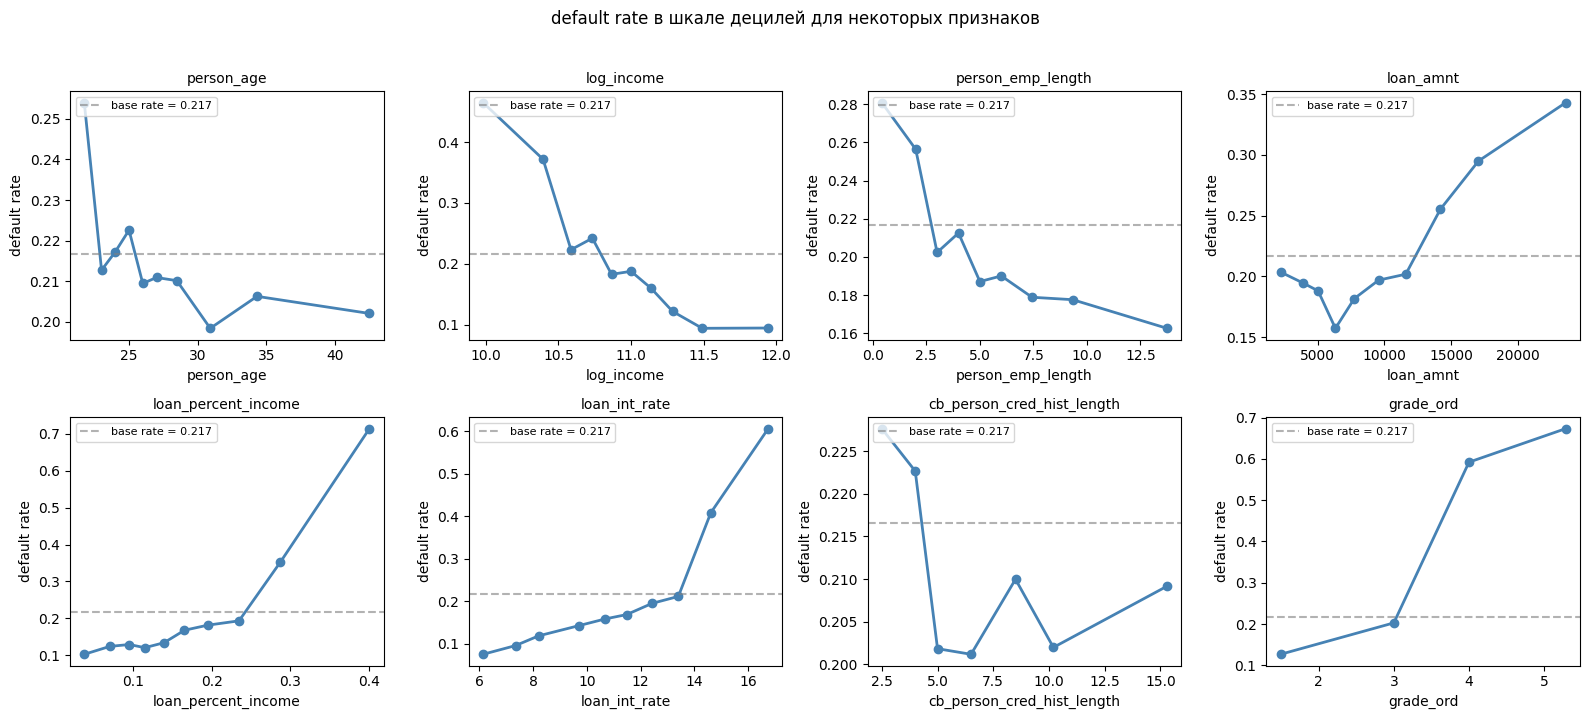

In [14]:
def bivariate_plot(ax, df, xcol, n_bins=10, title=None):
    df = df.copy()
    df['_bin'] = pd.qcut(df[xcol], q=n_bins, duplicates='drop')
    grouped = df.groupby('_bin', observed=True).agg(
        x=(xcol, 'mean'),
        y=('loan_status', 'mean'),
        n=('loan_status', 'size')
    ).reset_index(drop=True)
    ax.plot(grouped['x'], grouped['y'], 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.axhline(df['loan_status'].mean(), ls='--', color='gray', alpha=0.6,
               label=f"base rate = {df['loan_status'].mean():.3f}")
    ax.set_title(title or xcol, fontsize=10)
    ax.set_xlabel(xcol)
    ax.set_ylabel('default rate')
    ax.legend(fontsize=8, loc='upper left')
    return grouped

cont_to_plot = ['person_age', 'log_income', 'person_emp_length',
                'loan_amnt', 'loan_percent_income', 'loan_int_rate',
                'cb_person_cred_hist_length', 'grade_ord']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, cont_to_plot):
    bivariate_plot(ax, data, col, n_bins=10)
fig.suptitle('default rate в шкале децилей для некоторых признаков',
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

Можно сделать такие выводы:

1.   $\texttt{person_age}$: мы видим, что убывание конечно не монотонное, но и  возможную квадратическую зависимость тут не видно, поскольку на последнем дециле наша зависимость показывает убывание.
2.   $\texttt{log_income}$: практически монотонно убывает (есть несколько децилей, на которых есть возрастание, однако это возрастание незначительное, относительно убывания на других децилях);
3.   $\texttt{loan_int_rate}$: монотонно возрастает, тоже пологий подъем как и в случае loan\_percent\_income ~--- но этот признак сильно коррелирует с grade (а именно, $\rho = 0.93$), поэтому неудивительно, что график для grade\_ord так похож на этот. В дальнейшем мы оставим только один из этих признаков.

4.   $\texttt{cb_person_cred_hist_length}$: default rate сначала резко падает,
  потом на 4-5 дециле происходит некоторый скачок и спуск, потом незначительное возрастание). Первый дециль
 соответствует самым новым заёмщикам с историей меньше лет -- у них
ещё недостаточно информации для оценки риска, и default rate выше базового уровня. Далее, для клиентов из 2-3-го дециля, у банка появляется необходимая база и они уже не доверяют деньги ненадежным клиентам.


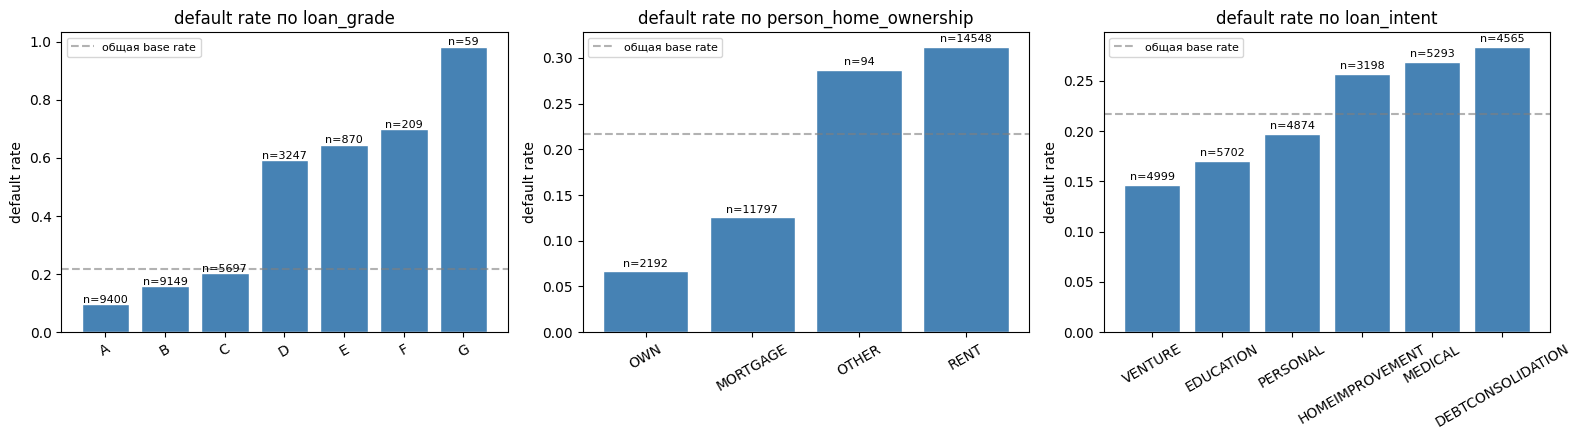

In [15]:
def cat_bar(ax, col, title):
    g = data.groupby(col).agg(
        rate=('loan_status', 'mean'),
        n=('loan_status', 'size'),
    ).sort_values('rate')
    ax.bar(g.index.astype(str), g['rate'], color='steelblue', edgecolor='white')
    for i, (idx, row) in enumerate(g.iterrows()):
        ax.text(i, row['rate'] + 0.005, f"n={int(row['n'])}", ha='center', fontsize=8)
    ax.axhline(data['loan_status'].mean(), ls='--', color='gray', alpha=0.6,
               label='общая base rate')
    ax.set_title(title)
    ax.set_ylabel('default rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cat_bar(axes[0], '_grade_orig',  'default rate по loan_grade')
cat_bar(axes[1], '_home_orig',   'default rate по person_home_ownership')
cat_bar(axes[2], '_intent_orig', 'default rate по loan_intent')
fig.tight_layout()
plt.show()


Из данных столбчаитых диаграмм мы делаем вывод, что собственная квартира, как и ипотека, не дает высокого default\_rate, в то время как аренда и другое (либо отсутствие жилья, либо жизнь с родителями, либо что-то еще) повышает риск дефолта заемщика. Очевидно, что взятие кредита как рефинансирование старых кредитов также не приводит к чему-то хорошем, о чем свидетельствует 3-я диаграмма. 1-ая диаграмма еще раз подтвердила нашу гипотезу о том, что банковские рейтинги очень эффективны.

А теперь посмотрим как связаны некоторые числовые признаки с условием того случится ли у человека дефолт.

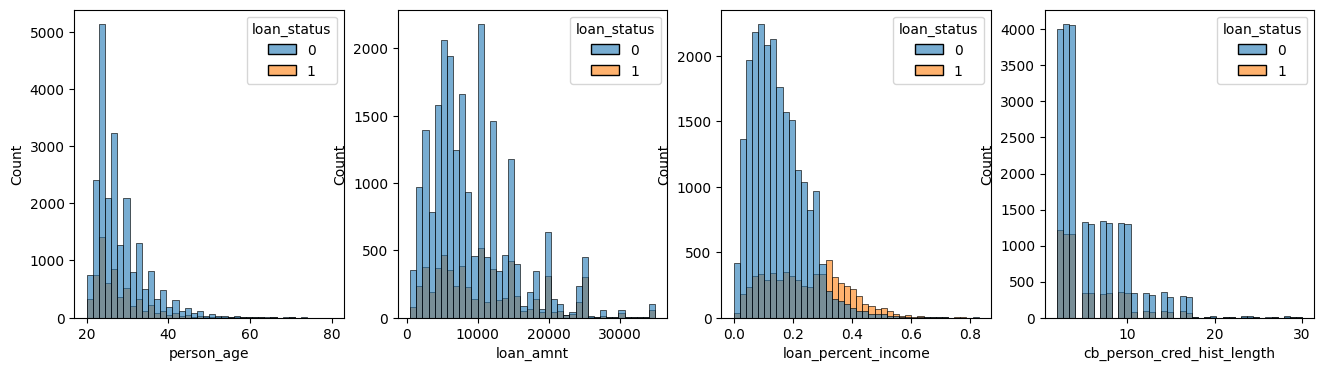

In [16]:
numeric_cols = ['person_age', 'loan_amnt',
                'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=data, x=col, hue='loan_status', bins=40, alpha=0.6, ax=ax)


Как мы видим, person\_age, loan\_amnt, cb\_person\_history\_length имеют практически одинаковое распределение при разных loan\_status. Это наталкивает нас на мысль, что коэффициенты в модели при данных переменных будут нулевыми, так как они слабо объясняют целнвую переменную. А вот распределение loan\_percent\_income уже отличается. Люди, которые в будущем объявят дефолт намного чаще берут в долг суммы, которые составляют значительнубю долю в их заработной плате.

Удалим наконец признак, который определяется сотрудниками банка на основании других признаков, из-за чего вносит мультиколлинеарность.

In [17]:
data = data.drop('loan_int_rate', axis=1)


Посмотрим может ли нам помочь редуцировать размерность метод главных компонент.

In [18]:
data.drop(['person_income', '_grade_orig', '_home_orig', '_intent_orig', 'grade_ord'], axis =1, inplace = True)
data

,person_age,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length,prev_default,home_OTHER,home_OWN,home_RENT,...,intent_HOMEIMPROVEMENT,intent_MEDICAL,intent_VENTURE,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,log_income
0,21,5.0,1000,0,0.10,2,0,0,1,0,...,0,0,0,1,0,0,0,0,0,9.169518
1,25,1.0,5500,1,0.57,3,0,0,0,0,...,0,1,0,0,1,0,0,0,0,9.169518
2,23,4.0,35000,1,0.53,2,0,0,0,1,...,0,1,0,0,1,0,0,0,0,11.089805
3,24,8.0,35000,1,0.55,4,1,0,0,1,...,0,1,0,0,1,0,0,0,0,10.904119
4,21,2.0,2500,1,0.25,2,0,0,1,0,...,0,0,1,0,0,0,0,0,0,9.200290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28626,57,1.0,5800,0,0.11,30,0,0,0,0,...,0,0,0,0,1,0,0,0,0,10.878047
28627,54,4.0,17625,0,0.15,19,0,0,0,0,...,0,0,0,0,0,0,0,0,0,11.695247
28628,65,3.0,35000,1,0.46,28,0,0,0,1,...,1,0,0,1,0,0,0,0,0,11.238489
28629,56,5.0,15000,0,0.10,26,0,0,0,0,...,0,0,0,1,0,0,0,0,0,11.918391


In [19]:
y = data['loan_status'].to_numpy()
X = data.drop(columns=['loan_status']).astype(float).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

In [20]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

In [21]:
pca = PCA()
pca.fit(X_tr_s)

explained_variance_ratio = pca.explained_variance_ratio_
cumsum = np.cumsum(explained_variance_ratio)

print("Доля дисперсии на каждой компоненте:", explained_variance_ratio)
print("Накопленная доля дисперсии:", cumsum)

Доля дисперсии на каждой компоненте: [0.10118501 0.08735791 0.07814956 0.07430679 0.06310911 0.05825589
 0.05739865 0.05530743 0.05246534 0.05208801 0.04872742 0.04801413
 0.04755616 0.04707907 0.03903238 0.03248407 0.02576441 0.01264848
 0.00974046 0.00577549 0.00355423]
Накопленная доля дисперсии: [0.10118501 0.18854292 0.26669248 0.34099927 0.40410838 0.46236427
 0.51976292 0.57507035 0.62753569 0.6796237  0.72835112 0.77636524
 0.8239214  0.87100047 0.91003286 0.94251693 0.96828134 0.98092982
 0.99067028 0.99644577 1.        ]


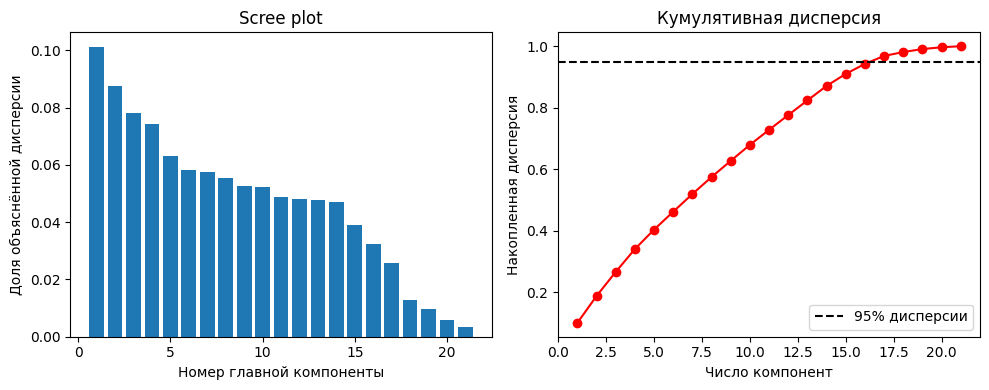

In [22]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Scree plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Кумулятивная дисперсия')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% дисперсии')
plt.legend()
plt.tight_layout()
plt.show()

Выделить какие-то 3-5 признаков, которые бы объясняли большую часть дисперсии не получается, поэтому делать поворот осей (применять pca к нашим данным для дальнейших исследований с измененным признаковым пространством) мы не будем.

# Модели

Первая модель, которую мы рассмотрим, будет логистическая регресссия. Методом проб и ошибок мною был выбран порог вероятности для класса 1 равный 0.35. То есть мы причисляем объект к классу 1 (то есть говорим, что он дефолтнется), если вероятность этого события больше либо равна 0.35. Сделано это из соображений максимизации recall, который очень важен для нашей задачи.

Вообще говоря, Порог $t$
должен выбираться таким образом, чтобы был достигнут в некотором смылсе баланс между FN, FP. Говоря фразу "В некотором смысле", мы подразумеваем, что в кредитном скоринге важнее, конечно, FN (мы хотим его максимально уменьшить, так как это те люди, которым мы дадим кредит, а они нам его не вернут, что приведет к разорению банка) но и слишком большой FP нас устраивать не будет -- у банка не будет возможноти на ком-то заработать денег, если всем отклонять запросы в займе.

In [23]:
param_grid = {
    'penalty': ['l1','l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
}
grid = GridSearchCV(
    LogisticRegression(max_iter=4000, fit_intercept=False),
    param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)
best = grid.best_estimator_

print('Best params:', grid.best_params_)
print(f'CV AUC:   {grid.best_score_:.4f}')

y_proba = best.predict_proba(X_test)[:, 1]
new_threshold = 0.35
y_pred = (y_proba >= new_threshold).astype(int)

print(f'Test AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(classification_report(y_test, y_pred, target_names=['paid','default'], digits=4))

Best params: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
CV AUC:   0.8733
Test AUC: 0.8716
              precision    recall  f1-score   support

        paid     0.9191    0.9120    0.9155      4532
     default     0.6756    0.6954    0.6854      1195

    accuracy                         0.8668      5727
   macro avg     0.7973    0.8037    0.8004      5727
weighted avg     0.8683    0.8668    0.8675      5727



recall получился 0.69 -- не очень хорошо, но при дальнейшем снижении порога сильно падает precision.

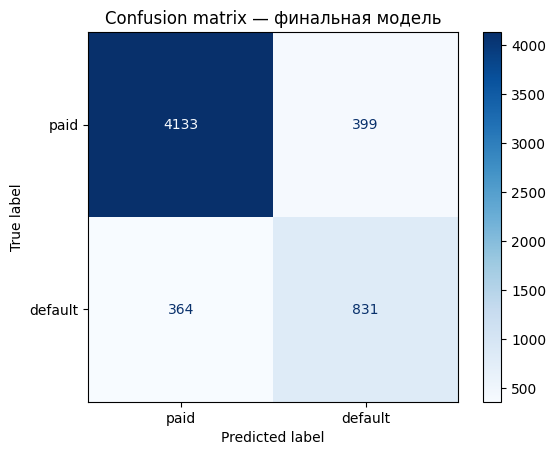

In [24]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['paid','default']).plot(cmap='Blues')
plt.title('Confusion matrix — финальная модель')
plt.show()

Радует также и то, что признаков переобучения не обнаружено, так как AUC-метрика примерно одинаковая и на train и на test.

Построим, наконец, roc-кривую.

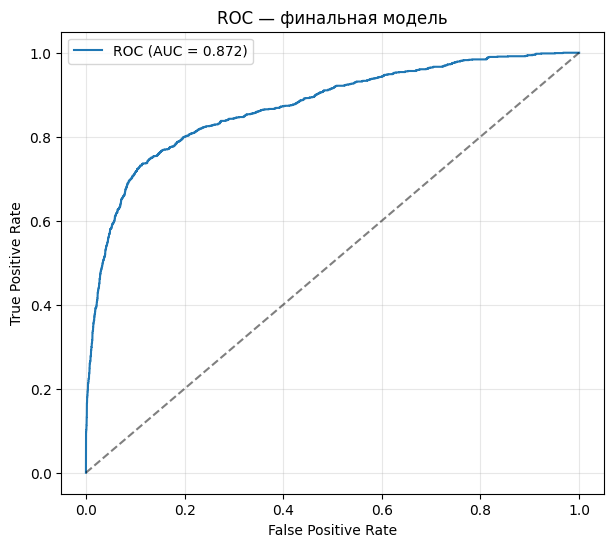

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--',alpha=.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — финальная модель')
plt.legend(); plt.grid(alpha=.3); plt.show()

Модель логистиечской регрессии с регуляризацией показала себя весьма неплохо, но, тем не менее, мы пойдем дальше и опробуем еще некоторые модели.

А именно, второй моделью у нас станет градиентный бустинг и такая его реализация как XGBoost. Параметры будем подбирать на кросс-валидации, осуществляемой с помощью RandomizedSearchCV

In [36]:
X_tr_boost = scaler.fit_transform(X_train)
X_te_boost = scaler.transform(X_test)

param_dist = {
    'n_estimators': [100, 250, 500],
    'max_depth': [3,5,7],
    'learning_rate': np.linspace(0.005, 0.02, 5),
    'subsample': np.linspace(0.5, 1.0, 10),
    'colsample_bytree': np.linspace(0.5, 1.0, 10),
    'gamma': [0, 0.5, 1, 2],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}

# Инициализация базового классификатора
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_tr_boost, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучшее качество (CV ROC-AUC):", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры: {'subsample': np.float64(0.9444444444444444), 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': np.float64(0.02), 'gamma': 2, 'colsample_bytree': np.float64(0.9444444444444444)}
Лучшее качество (CV ROC-AUC): 0.9415723380688144


Оценим теперь качество на тестовой выборке

In [37]:
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_te_boost)[:, 1]
y_pred = (y_pred_proba >=0.35)
print(classification_report(y_test, y_pred))
print('Метрика AUC при этом:', roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4532
           1       0.93      0.73      0.82      1195

    accuracy                           0.93      5727
   macro avg       0.93      0.86      0.89      5727
weighted avg       0.93      0.93      0.93      5727

Метрика AUC при этом: 0.9393637803882757


Мы получили очень неплохое качество нашей модели. Бустинг показал гораздо более высокий показатель auc метрики.

Построим такде так называемую calibration curve, которая строится по децилям распределия, которое характерно данным и децилям распределения, которое нам выдвет модель, в данном случае -- XGBoost.

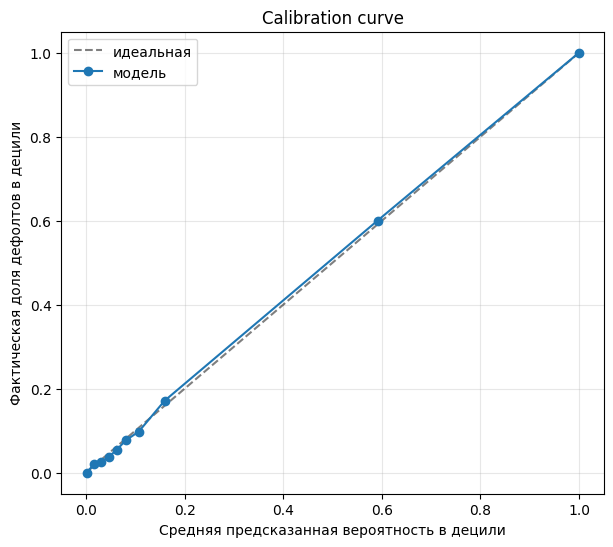

prob_pred: [0.001 0.017 0.031 0.047 0.062 0.08  0.107 0.159 0.591 1.   ]
prob_true: [0.    0.021 0.026 0.038 0.054 0.077 0.098 0.171 0.6   1.   ]


In [58]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(7,6))
plt.plot([0,1],[0,1],'k--',alpha=.5,label='идеальная')
plt.plot(prob_pred, prob_true, 'o-', label='модель')
plt.xlabel('Средняя предсказанная вероятность в децили')
plt.ylabel('Фактическая доля дефолтов в децили')
plt.title('Calibration curve')
plt.legend(); plt.grid(alpha=.3); plt.show()

print('prob_pred:', np.round(prob_pred, 3))
print('prob_true:', np.round(prob_true, 3))

И мы видим, что распределение, выдаваемое моделью почти идеально совпадает с эмпирическим распределением

Двигаемся дальше и у нас на очереди -- случайный лес

In [55]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': randint(3, 20),
    'min_samples_leaf': randint(5, 10),
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
    'class_weight': [None, 'balanced']
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [56]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=cv_strategy,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("\nЛучшие параметры:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)



Fitting 5 folds for each of 10 candidates, totalling 50 fits

Лучшие параметры:
  class_weight: None
  max_depth: 15
  max_features: 0.8
  min_samples_leaf: 7
  min_samples_split: 4
  n_estimators: 443
Лучший ROC-AUC на кросс-валидации: 0.9318


In [57]:
y_pred = (y_pred_proba >=0.35)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96      4532
           1       0.91      0.72      0.81      1195

    accuracy                           0.93      5727
   macro avg       0.92      0.85      0.88      5727
weighted avg       0.93      0.93      0.92      5727



Случанйый лес, как и градиентный бустинг, показал очень хороший результат, однако, все же XGBoost пока остаетсяя лучшим классификатором.